In [ ]:
import numpyro
import numpyro.distributions as dist
from numpyro.contrib.control_flow import scan
from numpyro.infer import MCMC, NUTS
from numpyro.infer import Predictive
# posterior samples
import numpy as np
from scipy.stats import norm, gaussian_kde
import arviz as az
import jax
import jax.numpy as jnp
from jax import random
import jax.random as random
from tqdm import tqdm
import pandas as pd
import numpy as np
import re
from datetime import datetime
from IPython.display import Markdown, display, HTML
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib as mpl
from matplotlib.lines import Line2D
import seaborn as sns
from statsmodels.tsa.filters.hp_filter import hpfilter

import warnings
warnings.simplefilter('ignore')
def get_model_number(model_str):
    nums = re.findall(r'\d+', model_str)
    if nums:
        return int(nums[-1])
    else:
        return None
colors = ['black', 'blue', 'orange', 'green', 'red', 'purple', 'brown', 'pink', 'gray']

from data_build import build_dataset
data = build_dataset("../data")

/opt/homebrew/Caskroom/miniforge/base/envs/bayes-env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Models

## CES
$$\pi_{t}	=\alpha\pi_{t-1}+(1-\alpha)\mathbb{E}_{t}\pi_{t+1}+\kappa_{t}x_{t}+v_{t}$$

## HSA
$$\pi_{t}	=\alpha\pi_{t-1}+(1-\alpha)\mathbb{E}_{t}\pi_{t+1}+\kappa_{t}x_{t}-\theta\hat{N}_{t}+v_{t}\\$$

## HSA, Joint decomposition
$$\pi_{t}	=\alpha\pi_{t-1}+(1-\alpha)\mathbb{E}_{t}\pi_{t+1}+\kappa x_{t}-\theta\hat{N}_{t}+v_{t}\\
N_{t}	=\hat{N_{t}}+\bar{N_{t}}\\
\hat{N_{t}}	=\rho_{1}\hat{N}_{t-1}+\rho_{2}\hat{N}_{t-2}+u_{t}\\
\bar{N_{t}}	=n+\bar{N}_{t-1}+\epsilon_{t}$$

## HSA, time-variant kappa
$$
\pi_{t}	=\alpha\pi_{t-1}+(1-\alpha)\mathbb{E}_{t}\pi_{t+1}+\kappa x_{t}-\theta\hat{N}_{t}+v_{t}\\
$$
- case 1 (deterministic)
$$
\kappa_{t}	=\kappa_{t-1}+\delta \Delta \bar{N}_{t}
$$
- case 2 (stochastic followed by normal distribution)
$$
\kappa_{t} \sim Normal(\kappa_{t-1}+\delta \Delta \bar{N}_{t}, \sigma_e^2)
$$

- case 3 (stochastic followed by truncated normal distribution)
$$
\kappa_{t} \sim TruncNormal(\kappa_{t-1}+\delta \Delta \bar{N}_{t}, \sigma_e^2, low=0)
$$

## HSA, time-variant kappa, joint decomposition
$$
\pi_{t}	=\alpha\pi_{t-1}+(1-\alpha)\mathbb{E}_{t}\pi_{t+1}+\kappa x_{t}-\theta\hat{N}_{t}+v_{t}\\
x_{t}   = \phi_1 x_{t-1} + \phi_2 \hat{N_{t}}+e_{t}\\
N_{t}	=\hat{N_{t}}+\bar{N_{t}}\\
\hat{N_{t}}	=\rho_{1}\hat{N}_{t-1}+\rho_{2}\hat{N}_{t-2}+u_{t}\\
\bar{N_{t}}	=n+\bar{N}_{t-1}+\epsilon_{t}\\
\kappa_{t}	=\kappa_{t-1}+\delta \Delta \bar{N}_{t}
$$

# Prior distributions

In [3]:
alpha_mu = 0.5
alpha_sigma = 0.2
kappa_mu = 0.1
kappa_sigma = 0.2
theta_mu = 0.1
theta_sigma = 0.2
delta_mu = 0.1
delta_sigma = 0.2
beta_mu = 0.1
beta_sigma = 0.2
def set_prior_distributions():
    priors = {
        # NKPC params
        "alpha"      : dist.Normal(alpha_mu, alpha_sigma),
        "kappa"      : dist.Normal(kappa_mu, kappa_sigma),
        "kappa0"     : dist.Normal(kappa_mu, kappa_sigma),
        "theta"      : dist.Normal(theta_mu, theta_sigma), 
        "delta"      : dist.Normal(delta_mu, delta_sigma),  
        "beta"       : dist.Normal(beta_mu, beta_sigma), 
        # Sigma
        "n"          : dist.Normal(0, 1), 
        # non informative priors
        "sigma_u"    : dist.InverseGamma(0.001, 0.001),  
        "sigma_eps"  : dist.InverseGamma(0.001, 0.001),  
        "sigma_v"    : dist.InverseGamma(0.001, 0.001),  
        "sigma_mu"   : dist.InverseGamma(0.001, 0.001),  
        "sigma_e"    : dist.InverseGamma(0.001, 0.001),  
        "sigma_eta"  : dist.InverseGamma(0.001, 0.001),  
    }
    return priors

# Estimation

In [4]:
# ---------------- MCMC run configuration ---------------
warmup = 1000
samples = 19000
chains = 2
# Target acceptance rate: lower values speed up sampling but may increase divergences.
TARGET_ACCEPT = 0.95
CHAIN_METHOD = "parallel"
PROGRESS_BAR = True

In [5]:
# models
## =================================================================================
# CES
def model_ces(pi, pi_prev, pi_expect, x, N, Nbar, Nhat, l):
    priors = set_prior_distributions()
    # NKPC params
    alpha = numpyro.sample("alpha", priors["alpha"])
    kappa = numpyro.sample("kappa", priors["kappa"])
    # Sigma
    sigma_v = numpyro.sample("sigma_v", priors["sigma_v"])
    # model
    pi_pred = alpha * pi_prev + (1-alpha) * pi_expect + kappa * x
    numpyro.sample(f"pi_obs", numpyro.distributions.Normal(pi_pred, sigma_v), obs=pi)
## =================================================================================
# HSA
def model_hsa(pi, pi_prev, pi_expect, x, N, Nbar, Nhat, l):
    priors = set_prior_distributions()
    # NKPC params
    alpha = numpyro.sample("alpha", priors["alpha"])
    kappa = numpyro.sample("kappa", priors["kappa"])
    theta = numpyro.sample("theta", priors["theta"])
    # Sigma
    sigma_v = numpyro.sample("sigma_v", priors["sigma_v"])
    # model
    pi_pred = alpha * pi_prev + (1-alpha) * pi_expect + kappa * x - theta * Nhat
    numpyro.sample(f"pi_obs", numpyro.distributions.Normal(pi_pred, sigma_v), obs=pi)
## =================================================================================
# HSA joint decomposition
def model_hsa_decomp(pi, pi_prev, pi_expect, x, N, Nbar, Nhat, l):
    priors = set_prior_distributions()
    # NKPC params
    alpha = numpyro.sample("alpha",priors["alpha"])
    theta = numpyro.sample("theta", priors["theta"])
    kappa = numpyro.sample("kappa", priors["kappa"])
    # State equation (N) params
    r = numpyro.sample("r", dist.Uniform(-1,1))      
    p = numpyro.sample("p", dist.Uniform(0.1, 0.9))  
    rho_1 = 2 * r * jnp.cos(jnp.pi * p)
    rho_2 = -r ** 2
    numpyro.deterministic("rho_1", rho_1) # Nhat AR1 coeff
    numpyro.deterministic("rho_2", rho_2) # Nhat AR2 coeff
    n = numpyro.sample("n", priors["n"])
    # Sigma
    sigma_v  = numpyro.sample("sigma_v", priors["sigma_v"])      
    sigma_u  = numpyro.sample("sigma_u", priors["sigma_u"])      
    sigma_eps = numpyro.sample("sigma_eps", priors["sigma_eps"]) 
    # initial 
    bar_N_0  = numpyro.sample("bar_N_0", dist.Normal(N[0], 1))   # Nbar init
    hat_N_0  = numpyro.sample("hat_N_0", dist.Normal(0, .05))    # Nhat init
    hat_N_1  = numpyro.sample("hat_N_1", dist.Normal(0, .05))    # Nhat init
    # state space model
    timesteps = jnp.arange(l)
    t = 0
    def transition(carry, _):        
        Nbar_prev = carry[0]
        Nhat_prev_1 = carry[1]
        Nhat_prev_2 = carry[2]
        t = carry[3]
        # trend 
        Nbar_t = numpyro.sample("Nbar_t", dist.Normal(n + Nbar_prev, sigma_eps))
        # N (Nbar + Nhat = observed N)
        Nhat_obs = N[t] - Nbar_t
        # cycle
        numpyro.sample("Nhat_pred", dist.Normal(rho_1 * Nhat_prev_1 + rho_2 * Nhat_prev_2, sigma_u), obs=Nhat_obs)
        Nhat_t = numpyro.deterministic("Nhat_t", Nhat_obs) 
        # pi
        pi_pred = alpha * pi_prev[t] + (1-alpha) * pi_expect[t] + kappa * x[t] - theta * Nhat_t
        numpyro.sample(f"pi_obs", dist.Normal(pi_pred, sigma_v), obs=pi[t])
        t = t + 1
        return [Nbar_t , Nhat_t, Nhat_prev_1 , t], None
    scan(transition, [bar_N_0, hat_N_1, hat_N_0, t], timesteps)
## =================================================================================
# HSA joint decomposition, X error
def model_hsa_decomp_xstar(pi, pi_prev, pi_expect, x, N, Nbar, Nhat, l):
    priors = set_prior_distributions()
    # NKPC params
    alpha = numpyro.sample("alpha",priors["alpha"])
    theta = numpyro.sample("theta", priors["theta"])
    kappa = numpyro.sample("kappa", priors["kappa"])
    # State equation (N) params
    r = numpyro.sample("r", dist.Uniform(-1,1))      
    p = numpyro.sample("p", dist.Uniform(0.1, 0.9))  
    rho_1 = 2 * r * jnp.cos(jnp.pi * p)
    rho_2 = -r ** 2
    numpyro.deterministic("rho_1", rho_1) # Nhat AR1 coeff
    numpyro.deterministic("rho_2", rho_2) # Nhat AR2 coeff
    n = numpyro.sample("n", priors["n"])
    # Sigma
    sigma_v  = numpyro.sample("sigma_v", priors["sigma_v"])      
    sigma_u  = numpyro.sample("sigma_u", priors["sigma_u"])      
    sigma_eps = numpyro.sample("sigma_eps", priors["sigma_eps"]) 
    sigma_e = numpyro.sample("sigma_e", priors["sigma_e"])
    # initial 
    bar_N_0  = numpyro.sample("bar_N_0", dist.Normal(N[0], 1))   # Nbar init
    hat_N_0  = numpyro.sample("hat_N_0", dist.Normal(0, .05))    # Nhat init
    hat_N_1  = numpyro.sample("hat_N_1", dist.Normal(0, .05))    # Nhat init
    # state space model
    timesteps = jnp.arange(l)
    t = 0
    def transition(carry, _):        
        Nbar_prev = carry[0]
        Nhat_prev_1 = carry[1]
        Nhat_prev_2 = carry[2]
        t = carry[3]
        x_star = numpyro.sample(f"xstar", dist.Normal(x[t], sigma_e))
        # trend 
        Nbar_t = numpyro.sample("Nbar_t", dist.Normal(n + Nbar_prev, sigma_eps))
        # N (Nbar + Nhat = observed N)
        Nhat_obs = N[t] - Nbar_t
        # cycle
        numpyro.sample("Nhat_pred", dist.Normal(rho_1 * Nhat_prev_1 + rho_2 * Nhat_prev_2, sigma_u), obs=Nhat_obs)
        Nhat_t = numpyro.deterministic("Nhat_t", Nhat_obs) 
        # pi
        pi_pred = alpha * pi_prev[t] + (1-alpha) * pi_expect[t] + kappa * x_star - theta * Nhat_t
        numpyro.sample(f"pi_obs", dist.Normal(pi_pred, sigma_v), obs=pi[t])
        t = t + 1
        return [Nbar_t , Nhat_t, Nhat_prev_1 , t], None
    scan(transition, [bar_N_0, hat_N_1, hat_N_0, t], timesteps)
## =================================================================================
# HSA time-varying kappa
def model_hsa_tv_case1(pi, pi_prev, pi_expect, x, N, Nbar, Nhat, l):
    priors = set_prior_distributions()
    # NKPC params
    alpha = numpyro.sample("alpha",priors["alpha"])
    kappa0 = numpyro.sample("kappa0", priors["kappa0"])
    theta = numpyro.sample("theta", priors["theta"])
    delta = numpyro.sample("delta", dist.Normal(0, 1))
    # Sigma
    sigma_v  = numpyro.sample("sigma_v", priors["sigma_v"])      
    # state space model
    timesteps = jnp.arange(l)
    t = 0
    def transition(carry, _):        
        kappa_prev = carry[0]
        t = carry[1]        
        # kappa      
        dNbar = jnp.concatenate([jnp.array([0.0]), jnp.diff(Nbar)])
        kappa_t = kappa_prev + delta * dNbar[t]
        numpyro.deterministic("kappa_t", kappa_t)         
        # pi
        pi_pred = alpha * pi_prev[t] + (1-alpha) * pi_expect[t] + kappa_t * x[t] - theta * Nhat[t]
        numpyro.sample(f"pi_obs", dist.Normal(pi_pred, sigma_v), obs=pi[t])
        t = t + 1
        return [kappa_t , t], None
    scan(transition, [kappa0, t], timesteps)
## =================================================================================
# HSA time-varying kappa
def model_hsa_tv_case1_xstar(pi, pi_prev, pi_expect, x, N, Nbar, Nhat, l):
    priors = set_prior_distributions()
    # NKPC params
    alpha = numpyro.sample("alpha",priors["alpha"])
    kappa0 = numpyro.sample("kappa0", priors["kappa0"])
    theta = numpyro.sample("theta", priors["theta"])
    delta = numpyro.sample("delta", dist.Normal(0, 1))
    # Sigma
    sigma_v  = numpyro.sample("sigma_v", priors["sigma_v"]) 
    sigma_e = numpyro.sample("sigma_e", priors["sigma_e"])     
    # state space model
    timesteps = jnp.arange(l)
    t = 0
    def transition(carry, _):        
        kappa_prev = carry[0]
        t = carry[1]        
        # kappa      
        dNbar = jnp.concatenate([jnp.array([0.0]), jnp.diff(Nbar)])
        kappa_t = kappa_prev + delta * dNbar[t]
        numpyro.deterministic("kappa_t", kappa_t)    
        x_star = numpyro.sample(f"xstar", dist.Normal(x[t], sigma_e))     
        # pi
        pi_pred = alpha * pi_prev[t] + (1-alpha) * pi_expect[t] + kappa_t * x_star - theta * Nhat[t]
        numpyro.sample(f"pi_obs", dist.Normal(pi_pred, sigma_v), obs=pi[t])
        t = t + 1
        return [kappa_t , t], None
    scan(transition, [kappa0, t], timesteps)
## =================================================================================
# HSA time-varying kappa and joint decomposition of N
def model_hsa_tv_decomp_case1(pi, pi_prev, pi_expect, x, N, Nbar, Nhat, l):
    priors = set_prior_distributions()
    # NKPC params
    alpha = numpyro.sample("alpha",priors["alpha"])
    theta = numpyro.sample("theta", priors["theta"])
    delta = numpyro.sample("delta", priors["delta"])
    # State equation (N) params
    r = numpyro.sample("r", dist.Uniform(-1,1))      
    p = numpyro.sample("p", dist.Uniform(0.1, 0.9))  
    rho_1 = 2 * r * jnp.cos(jnp.pi * p)
    rho_2 = -r ** 2
    numpyro.deterministic("rho_1", rho_1) # Nhat AR1 coeff
    numpyro.deterministic("rho_2", rho_2) # Nhat AR2 coeff
    n = numpyro.sample("n", priors["n"])
    # Sigma
    sigma_v  = numpyro.sample("sigma_v", priors["sigma_v"])      
    sigma_u  = numpyro.sample("sigma_u", priors["sigma_u"])      
    sigma_eps = numpyro.sample("sigma_eps", priors["sigma_eps"]) 
    # initial 
    bar_N_0  = numpyro.sample("bar_N_0", dist.Normal(N[0], 1))   # Nbar init
    hat_N_0  = numpyro.sample("hat_N_0", dist.Normal(0, .05))    # Nhat init
    hat_N_1  = numpyro.sample("hat_N_1", dist.Normal(0, .05))    # Nhat init
    kappa0 = numpyro.sample("kappa0", priors["kappa"])   # kappa init
    # state space model
    timesteps = jnp.arange(l)
    t = 0
    def transition(carry, _):        
        Nbar_prev = carry[0]
        Nhat_prev_1 = carry[1]
        Nhat_prev_2 = carry[2]
        kappa_prev = carry[3]
        t = carry[4]
        # trend 
        Nbar_t = numpyro.sample("Nbar_t", dist.Normal(n + Nbar_prev, sigma_eps))
        # N (Nbar + Nhat = observed N)
        Nhat_obs = N[t] - Nbar_t
        # cycle
        numpyro.sample("Nhat_pred", dist.Normal(rho_1 * Nhat_prev_1 + rho_2 * Nhat_prev_2, sigma_u), obs=Nhat_obs)
        Nhat_t = numpyro.deterministic("Nhat_t", Nhat_obs) 
        # kappa
        kappa_t = kappa_prev + delta *(Nbar_t - Nbar_prev)
        numpyro.deterministic("kappa_t", kappa_t)    
        # pi
        pi_pred = alpha * pi_prev[t] + (1-alpha) * pi_expect[t] + kappa_t * x[t] - theta * Nhat_t
        numpyro.sample(f"pi_obs", dist.Normal(pi_pred, sigma_v), obs=pi[t])
        t = t + 1
        return [Nbar_t, Nhat_t, Nhat_prev_1, kappa_t, t], None
    scan(transition, [bar_N_0, hat_N_0, hat_N_1, kappa0, t], timesteps)

## =================================================================================
# HSA time-varying kappa and joint decomposition of N, X 
def model_hsa_tv_decomp_case1_xstar(pi, pi_prev, pi_expect, x, N, Nbar, Nhat, l):
    priors = set_prior_distributions()
    # NKPC params
    alpha = numpyro.sample("alpha",priors["alpha"])
    theta = numpyro.sample("theta", priors["theta"])
    delta = numpyro.sample("delta", priors["delta"])
    # State equation (N) params
    r = numpyro.sample("r", dist.Uniform(-1,1))      
    p = numpyro.sample("p", dist.Uniform(0.1, 0.9))  
    rho_1 = 2 * r * jnp.cos(jnp.pi * p)
    rho_2 = -r ** 2
    numpyro.deterministic("rho_1", rho_1) # Nhat AR1 coeff
    numpyro.deterministic("rho_2", rho_2) # Nhat AR2 coeff
    n = numpyro.sample("n", priors["n"])
    # Sigma
    sigma_e = numpyro.sample("sigma_e", priors["sigma_e"])
    sigma_v  = numpyro.sample("sigma_v", priors["sigma_v"])      
    sigma_u  = numpyro.sample("sigma_u", priors["sigma_u"])      
    sigma_eps = numpyro.sample("sigma_eps", priors["sigma_eps"]) 
    # initial 
    bar_N_0  = numpyro.sample("bar_N_0", dist.Normal(N[0], 1))   # Nbar init
    hat_N_0  = numpyro.sample("hat_N_0", dist.Normal(0, .05))    # Nhat init
    hat_N_1  = numpyro.sample("hat_N_1", dist.Normal(0, .05))    # Nhat init
    kappa0 = numpyro.sample("kappa0", priors["kappa"])   # kappa init
    # state space model
    timesteps = jnp.arange(l)
    t = 0
    def transition(carry, _):        
        Nbar_prev = carry[0]
        Nhat_prev_1 = carry[1]
        Nhat_prev_2 = carry[2]
        kappa_prev = carry[3]
        t = carry[4]
        # trend 
        Nbar_t = numpyro.sample("Nbar_t", dist.Normal(n + Nbar_prev, sigma_eps))
        # N (Nbar + Nhat = observed N)
        Nhat_obs = N[t] - Nbar_t
        # cycle
        numpyro.sample("Nhat_pred", dist.Normal(rho_1 * Nhat_prev_1 + rho_2 * Nhat_prev_2, sigma_u), obs=Nhat_obs)
        Nhat_t = numpyro.deterministic("Nhat_t", Nhat_obs) 
        # kappa
        kappa_t = kappa_prev + delta *(Nbar_t - Nbar_prev)
        numpyro.deterministic("kappa_t", kappa_t)    
        x_star = numpyro.sample(f"xstar", dist.Normal(x[t-1] + Nhat_t, sigma_e))
        # pi
        pi_pred = alpha * pi_prev[t] + (1-alpha) * pi_expect[t] + kappa_t * x_star - theta * Nhat_t
        numpyro.sample(f"pi_obs", dist.Normal(pi_pred, sigma_v), obs=pi[t])
        t = t + 1
        return [Nbar_t, Nhat_t, Nhat_prev_1, kappa_t, t], None
    scan(transition, [bar_N_0, hat_N_0, hat_N_1, kappa0, t], timesteps)



In [6]:
# for reproducibility
rng_key = jax.random.PRNGKey(0)
rng_keys = jax.random.split(rng_key, chains)
numpyro.enable_x64()

In [16]:
# for MCMC
pi = jnp.array(data['pi_cpi'],dtype=jnp.float64)
pi_prev = jnp.array(data['pi_cpi_prev'],dtype=jnp.float64)
pi_expect = jnp.array(data['Epi_spf_cpi'],dtype=jnp.float64)
N = jnp.array(data['N'],dtype=jnp.float64)
Nhat = jnp.array(data['N_BN_cycle'],dtype=jnp.float64)
Nbar = jnp.array(data['N_BN_trend'],dtype=jnp.float64)
Y = jnp.array(data['output'],dtype=jnp.float64)
x_markup = jnp.array(1/data['markup'],dtype=jnp.float64)
x_output_gap = jnp.array(data['output_gap_BN'],dtype=jnp.float64)
x_markup_bn = jnp.array(data['markup_BN_inv'],dtype=jnp.float64)
x_unempgap = jnp.array(data['unemp_gap'],dtype=jnp.float64)

In [17]:
# for results
# SDDR
def sddr_alpha(idata):
    """BF_01 = posterior_density_at_0 / prior_density_at_0"""
    # posterior draws of kappa
    post = np.asarray(idata.posterior["alpha"]).ravel()
    post = post[np.isfinite(post)]
    if post.size < 10:
        return np.nan  # safety

    # posterior density at 0 (KDE)
    kde = gaussian_kde(post)
    post_at0 = float(kde.evaluate([0.0])[0])
    # prior density at 0
    prior_at0 = norm.pdf(0.0, loc=alpha_mu, scale=alpha_sigma)
    return post_at0 / max(prior_at0, 1e-300)

def sddr_kappa(idata):
    """BF_01 = posterior_density_at_0 / prior_density_at_0"""
    # posterior draws of kappa
    post = np.asarray(idata.posterior["kappa"]).ravel()
    post = post[np.isfinite(post)]
    if post.size < 10:
        return np.nan  # safety

    # posterior density at 0 (KDE)
    kde = gaussian_kde(post)
    post_at0 = float(kde.evaluate([0.0])[0])
    # prior density at 0
    prior_at0 = norm.pdf(0.0, loc=kappa_mu, scale=kappa_sigma)
    return post_at0 / max(prior_at0, 1e-300)

def sddr_theta(idata):
    """BF_01 = posterior_density_at_0 / prior_density_at_0"""
    # posterior draws of kappa
    post = np.asarray(idata.posterior["theta"]).ravel()
    post = post[np.isfinite(post)]
    if post.size < 10:
        return np.nan  # safety
    # posterior density at 0 (KDE)
    kde = gaussian_kde(post)
    post_at0 = float(kde.evaluate([0.0])[0])
    # prior density at 0
    prior_at0 = norm.pdf(0.0, loc=theta_mu, scale=theta_sigma)
    return post_at0 / max(prior_at0, 1e-300)

def sddr_delta(idata):
    """BF_01 = posterior_density_at_0 / prior_density_at_0"""
    # posterior draws of kappa
    post = np.asarray(idata.posterior["delta"]).ravel()
    post = post[np.isfinite(post)]
    if post.size < 10:
        return np.nan  # safety

    # posterior density at 0 (KDE)
    kde = gaussian_kde(post)
    post_at0 = float(kde.evaluate([0.0])[0])
    # prior density at 0
    prior_at0 = norm.pdf(0.0, loc=delta_mu, scale=delta_sigma)
    return post_at0 / max(prior_at0, 1e-300)
# for plot
def plot_prior_posterior_grid(idatas, labels, params=("kappa","alpha","theta"),
                              figsize=(9,2.8), xlims=None):
    assert len(idatas) == len(labels)
    n_rows, n_cols = len(idatas), len(params)
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(figsize[0]*n_cols, figsize[1]*n_rows),
                             squeeze=False, sharey='col')

    priors = {"alpha": (alpha_mu, alpha_sigma),
              "kappa": (kappa_mu, kappa_sigma),
              "theta": (theta_mu, theta_sigma),
              "delta": (delta_mu, delta_sigma)}

    for i, (idata, label_row) in enumerate(zip(idatas, labels)):
        avail = set(idata.posterior.data_vars) if "posterior" in idata.__dict__ else set()
        for j, param in enumerate(params):
            ax = axes[i, j]
            if param in avail:
                az.plot_posterior(idata, var_names=[param], point_estimate=None,
                                  hdi_prob="hide", kind="kde", color="royalblue", ax=ax)
                if param in priors:
                    mu, sigma = priors[param]
                    if xlims and param in xlims:
                        xmin, xmax = xlims[param]
                    else:
                        xmin, xmax = mu - 5*sigma, mu + 5*sigma
                    x = np.linspace(xmin, xmax, 1000)
                    y = norm.pdf(x, mu, sigma)
                    ax.plot(x, y, "r--", lw=2, label="Prior")
            else:
                ax.set_xticks([]); ax.set_yticks([])

            if j == 0:
                ax.set_ylabel("Density", fontsize=11)
                # ax.set_title(label_row, fontsize=20, loc="left")
            ax.set_xlabel({"kappa": r"$\kappa$", "alpha": r"$\alpha$",
                           "theta": r"$\theta$", "delta": r"$\delta$"}.get(param, param), fontsize=16)
            if xlims and param in xlims: ax.set_xlim(xlims[param])

    legend_handles = [Line2D([0],[0], color="royalblue", lw=2, label="Posterior"),
                      Line2D([0],[0], color="red", lw=2, ls="--", label="Prior")]
    fig.legend(handles=legend_handles, fontsize=10, loc="lower center",
               ncol=2, frameon=False, bbox_to_anchor=(0.5, -0.02))
    plt.tight_layout()
    return fig

## Employment gap ($u^*-u$)

In [18]:
# fixed kappa
# CES
# Define all x-variables you want to test
model_dict = {
    "CES_emp": model_ces, 
    "HSA_emp": model_hsa,
    "HSA_decomp_emp": model_hsa_decomp,
    "HSA_tv_empgap_1": model_hsa_tv_case1,
    "HSA_tv_decomp_empgap_1": model_hsa_tv_decomp_case1,
}
# 1) model
dict_idata = {}
print("=== Run models ===")
for model_name, m in model_dict.items():
    print(f"Running NKPC model: {model_name}")
    kernel = NUTS(m, target_accept_prob=TARGET_ACCEPT)
    mcmc = MCMC(kernel, num_warmup=warmup, num_samples=samples, num_chains=chains, chain_method=CHAIN_METHOD, progress_bar=PROGRESS_BAR)
    mcmc.run(rng_keys, pi=pi, pi_prev=pi_prev, pi_expect=pi_expect, x=x_unempgap, N=N, Nhat=Nhat, Nbar=Nbar, l=len(pi))
    idata = az.from_numpyro(mcmc)
    dict_idata[model_name] = idata
    # Divergence diagnostics
    diverging = idata.sample_stats["diverging"].values
    ratio_div = float(np.mean(diverging))
    print(f"Divergence ratio for {model_name}: {ratio_div:.4%}")
print("\n=== All models finished ===\n")

=== Run models ===
Running NKPC model: CES_emp


sample: 100%|██████████| 20000/20000 [00:02<00:00, 6915.44it/s, 7 steps of size 6.10e-01. acc. prob=0.95]


Divergence ratio for CES_emp: 0.0000%
Running NKPC model: HSA_emp


sample: 100%|██████████| 20000/20000 [00:03<00:00, 5813.71it/s, 7 steps of size 5.03e-01. acc. prob=0.96]


Divergence ratio for HSA_emp: 0.0000%
Running NKPC model: HSA_decomp_emp


...

Divergence ratio for HSA_decomp_emp: 0.0000%
Running NKPC model: HSA_tv_empgap_1


sample: 100%|██████████| 20000/20000 [00:08<00:00, 2424.10it/s, 7 steps of size 3.57e-01. acc. prob=0.97] 


Divergence ratio for HSA_tv_empgap_1: 0.0000%
Running NKPC model: HSA_tv_decomp_empgap_1


sample: 100%|██████████| 20000/20000 [01:25<00:00, 232.84it/s, 255 steps of size 2.81e-02. acc. prob=0.94] 


Divergence ratio for HSA_tv_decomp_empgap_1: 0.0000%

=== All models finished ===



model,alpha,theta,delta,rho_1,rho_2,n
HSA_tv_decomp_empgap_1,"0.6240 [0.5160, 0.7280]","0.1830 [-0.1190, 0.4710]","0.0710 [0.0170, 0.1270]","1.7870 [1.7020, 1.8740]","-0.8860 [-0.9720, -0.8030]","-0.0150 [-0.0250, -0.0040]"


model,SDDR_BF01_alpha,SDDR_BF01_kappa,SDDR_BF01_theta,SDDR_BF01_delta
HSA_tv_decomp_empgap_1,0.0,nan,0.7183,0.3615


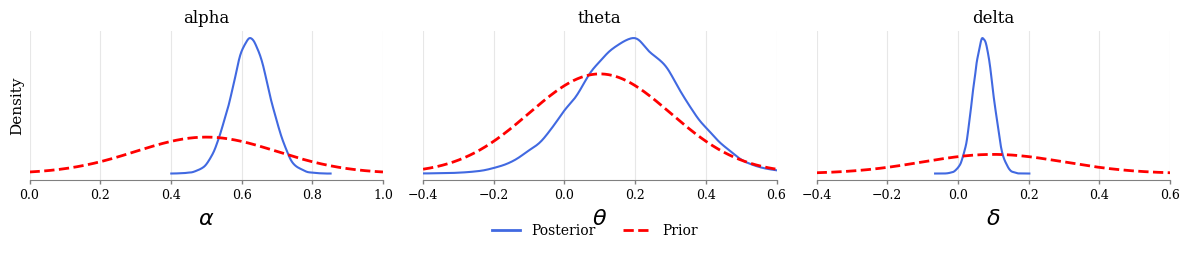

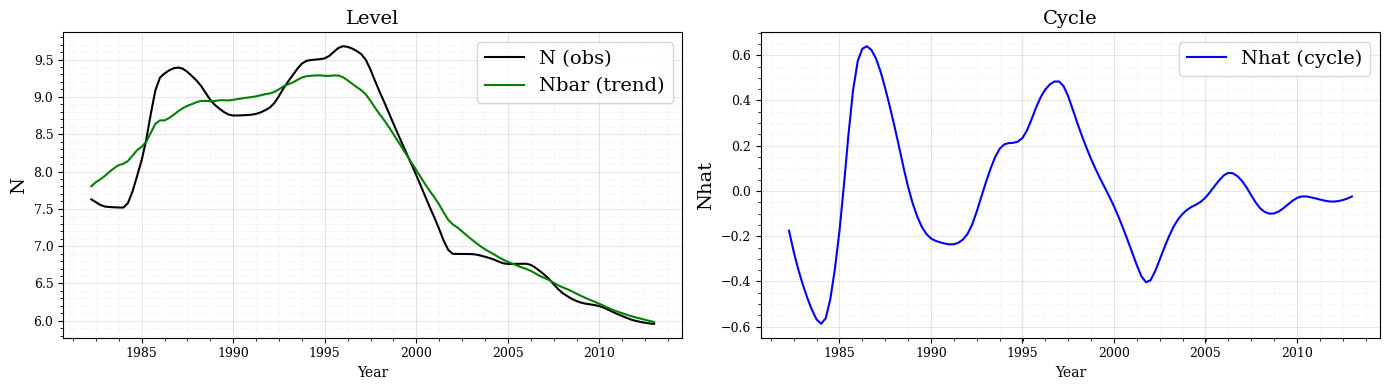

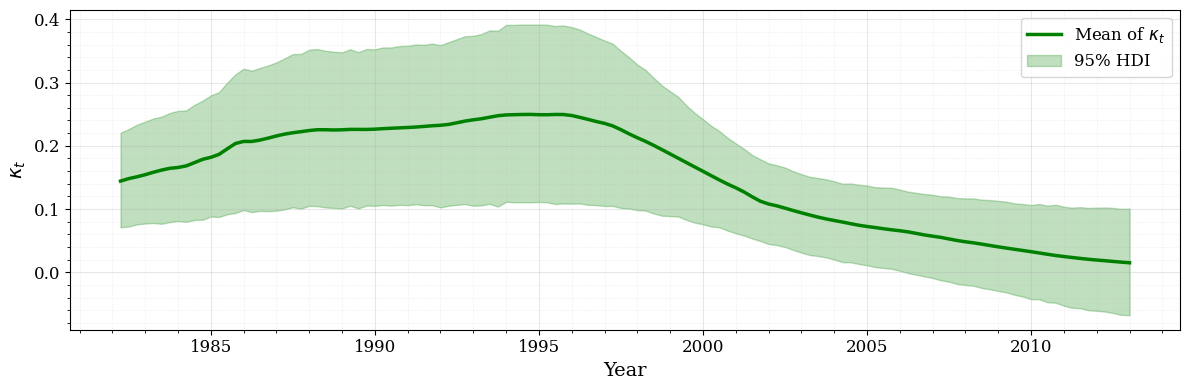

In [ ]:
# results
models_to_show ={
    "HSA_tv_decomp_empgap_1",
}
# dict_idata subset
dict_items_fill = {k: v for k, v in dict_idata.items() if k in models_to_show}
show_hdi = True
target_params = ["alpha", "theta", "delta","rho_1", "rho_2", "n"]
# ------- Summary table -------
summ_list = []
for model_name, idata in dict_items_fill.items():
    present = set(idata.posterior.data_vars)
    selected = list(present.intersection(target_params))
    if len(selected) == 0:
        continue
    # ArviZ summary
    s = az.summary(idata, var_names=selected, hdi_prob=0.95)
    s["param"] = s.index
    s["model"] = model_name
    s = s.reset_index(drop=True)
    s = s[["model", "param", "mean", "hdi_2.5%", "hdi_97.5%"]]
    summ_list.append(s)
summary_long = pd.concat(summ_list, ignore_index=True)

# ---- HDI on/off ----
if show_hdi:
    summary_long["value"] = summary_long.apply(
        lambda r: f"{r['mean']:.4f} [{r['hdi_2.5%']:.4f}, {r['hdi_97.5%']:.4f}]",
        axis=1
    )
else:
    summary_long["value"] = summary_long["mean"].map(lambda x: f"{x:.4f}")

# pivot
summary_wide = (
    summary_long.pivot_table(
        index="model",
        columns="param",
        values="value",
        aggfunc="first",
    )
    .reindex(columns=target_params)
    .reset_index()
    .rename_axis(None, axis=1)
)

display(HTML("<h3>Summary</h3>"))
display(summary_wide.style.hide(axis="index"))

# SDDR（kappa / theta）table
sddr_rows = []
for model_name, idata in dict_items_fill.items():
    try:
        bf01_alpha = sddr_alpha(idata)
    except Exception:
        bf01_alpha = np.nan
    try:
        bf01_kappa = sddr_kappa(idata)
    except Exception:
        bf01_kappa = np.nan
    try:
        bf01_theta = sddr_theta(idata)
    except Exception:
        bf01_theta = np.nan
    try:
        bf01_delta = sddr_delta(idata)
    except Exception:
        bf01_delta = np.nan
    sddr_rows.append({
        "model": model_name,
        "SDDR_BF01_alpha": bf01_alpha,
        "SDDR_BF01_kappa": bf01_kappa,
        "SDDR_BF01_theta": bf01_theta,
        "SDDR_BF01_delta": bf01_delta,
    })

df_sddr = pd.DataFrame(sddr_rows)
df_sddr["SDDR_BF01_alpha"] = df_sddr["SDDR_BF01_alpha"].map(lambda v: f"{v:.4}")
df_sddr["SDDR_BF01_theta"] = df_sddr["SDDR_BF01_theta"].map(lambda v: f"{v:.4}")
df_sddr["SDDR_BF01_delta"] = df_sddr["SDDR_BF01_delta"].map(lambda v: f"{v:.4}")


display(HTML("<h3>SDDR: kappa: Bayes Factor (BF01)</h3>"))
display(df_sddr.style.hide(axis="index"))

display(HTML("<h3>prior vs posterior </h3>"))
# 6) prior vs posterior 
params = ("alpha", "theta", "delta")
try:
    idatas = [idata for _, idata in dict_items_fill.items()]
    labels  = [name for name, _ in dict_items_fill.items()]
    fig = plot_prior_posterior_grid(
            figsize=(4,2.5),
            idatas=idatas,
            labels=labels,
            params=params,
            xlims={"kappa": (-0.15, 0.25), "alpha": (0, 1.0), "theta": (-0.4, 0.6), "delta": (-0.4, 0.6)})
    plt.show()
except Exception as e:
    print(f"[plot_prior_posterior_grid] error: {e}")


display(HTML("<h3>Decomposed N for Each Model</h3>"))

for model_name, idata in dict_items_fill.items():
    if "Nbar_t" in idata.posterior:

        # ---- Samples ----
        Nhat_samples = idata.posterior["Nhat_t"].values
        Nhat_samples = Nhat_samples.reshape(-1, Nhat_samples.shape[-1])
        Nhat_mean = np.mean(Nhat_samples, axis=0)

        Nbar_samples = idata.posterior["Nbar_t"].values
        Nbar_samples = Nbar_samples.reshape(-1, Nbar_samples.shape[-1])
        Nbar_mean = np.mean(Nbar_samples, axis=0)

        # ---- Figure: two panels ----
        fig, (ax1, ax2) = plt.subplots(
            ncols=2, figsize=(14, 4), sharex=True
        )

        # =========================
        # Left panel: Level
        # =========================
        ax1.plot(data["DATE"], data["N"], label="N (obs)", color="black")
        ax1.plot(data["DATE"], Nbar_mean, label="Nbar (trend)", color="green")
        ax1.set_title("Level", fontsize=14)
        ax1.set_ylabel("N", fontsize=14)
        ax1.legend(loc="upper right", fontsize=14)

        # =========================
        # Right panel: Cycle
        # =========================
        ax2.plot(data["DATE"], Nhat_mean, label="Nhat (cycle)", color="blue")
        ax2.set_title("Cycle", fontsize=14)
        ax2.set_ylabel("Nhat", fontsize=14)
        ax2.legend(loc="upper right", fontsize=14)

        # ---- X-axis formatting (shared) ----
        for ax in (ax1, ax2):
            ax.set_xlabel("Year")
            ax.xaxis.set_major_locator(mdates.YearLocator(5))
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
            ax.xaxis.set_minor_locator(mdates.YearLocator(1))
            ax.minorticks_on()
            ax.grid(which="major", linestyle="-", linewidth=0.75)
            ax.grid(which="minor", linestyle=":", linewidth=0.5)
        plt.tight_layout()
        plt.show()

# ===== Plot kappa_t for each model with 95% HDI =====
display(HTML("<h3>Latent Variable kappa_t (95% HDI) for Each Model</h3>"))
for model_name, idata in dict_items_fill.items():
        # Extract kappa_t samples from posterior
        if "kappa_t" in idata.posterior:
            kappa_samples = idata.posterior["kappa_t"].values
            # Flatten chain and draw dimensions: (chain, draw, time) -> (samples, time)
            kappa_samples = kappa_samples.reshape(-1, kappa_samples.shape[-1])
            
            # Calculate mean and 95% HDI using ArviZ
            kappa_mean = np.mean(kappa_samples, axis=0)
            kappa_hdi = az.hdi(kappa_samples, hdi_prob=0.95)
            kappa_lower = kappa_hdi[:, 0]
            kappa_upper = kappa_hdi[:, 1]
            
            # Moving average
            window = 5
            kappa_ma = pd.Series(kappa_mean).rolling(window=window, center=True).mean()
            
        # Plot
        plt.figure(figsize=(12, 4))

        plt.plot(
            data["DATE"], kappa_mean,
            label=r"Mean of $\kappa_t$",
            color="green",
            linewidth=2.5
        )

        plt.fill_between(
            data["DATE"], kappa_lower, kappa_upper,
            color="green",
            alpha=0.25,
            label="95% HDI"
        )

        # ---- Labels (bigger) ----
        plt.xlabel("Year", fontsize=14)
        plt.ylabel(r"$\kappa_t$", fontsize=14)

        # ---- Legend (bigger) ----
        plt.legend(fontsize=12)

        # ---- Ticks (bigger) ----
        plt.tick_params(axis="both", which="major", labelsize=12)
        plt.tick_params(axis="both", which="minor", labelsize=10)

        # ---- Grid ----
        plt.minorticks_on()
        plt.grid(which="major", linestyle="-", linewidth=0.75)
        plt.grid(which="minor", linestyle=":", linewidth=0.5)

        # ---- X-axis formatting ----
        ax = plt.gca()
        ax.xaxis.set_major_locator(mdates.YearLocator(5))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        ax.xaxis.set_minor_locator(mdates.YearLocator(1))

        plt.tight_layout()
        plt.show()

model,alpha,kappa,theta,delta
CES_emp,0.6390,0.0830,nan,nan
HSA_decomp_emp,0.6280,0.0880,0.1790,nan
HSA_emp,0.6240,0.0840,0.1320,nan
HSA_tv_decomp_empgap_1,0.6240,nan,0.1830,0.0710
HSA_tv_empgap_1,0.6290,nan,0.0890,0.0620


model,SDDR_BF01_kappa,SDDR_BF01_theta,SDDR_BF01_delta
CES_emp,0.2405,nan,nan
HSA_emp,0.1947,0.9101,nan
HSA_decomp_emp,0.138,0.7173,nan
HSA_tv_empgap_1,nan,1.505,0.954
HSA_tv_decomp_empgap_1,nan,0.7183,0.3615


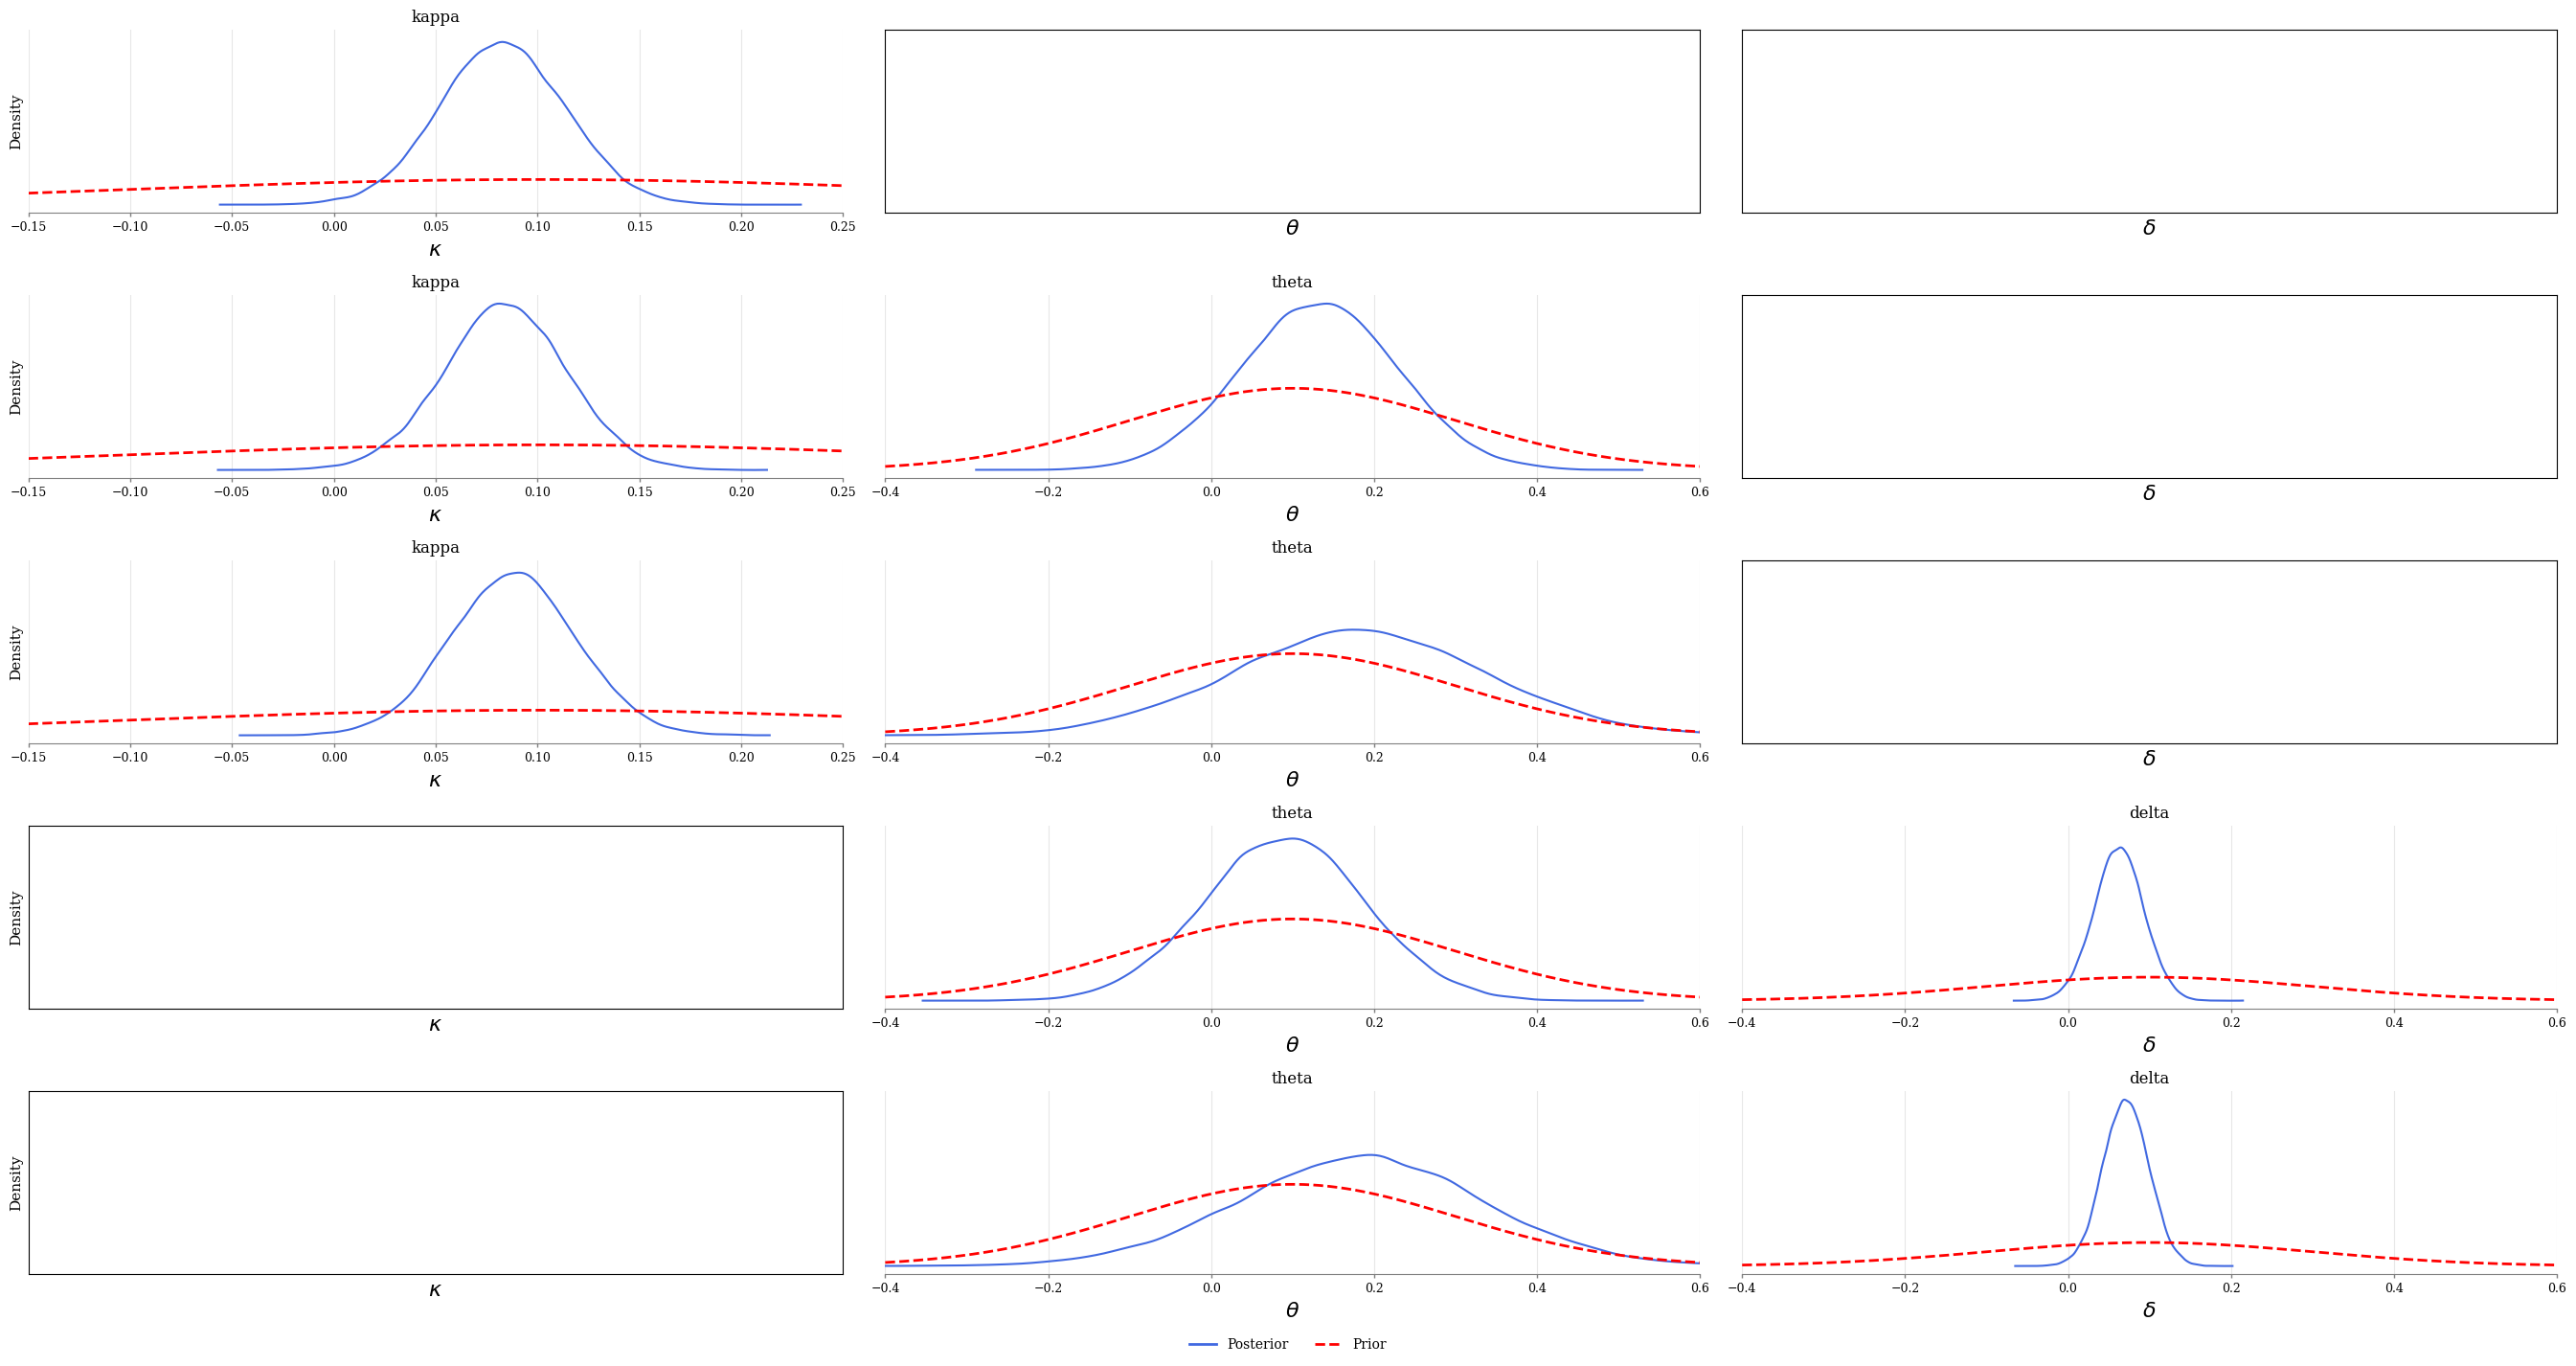

Model 'CES_emp' does not contain 'kappa_t' in posterior
Model 'HSA_emp' does not contain 'kappa_t' in posterior
Model 'HSA_decomp_emp' does not contain 'kappa_t' in posterior


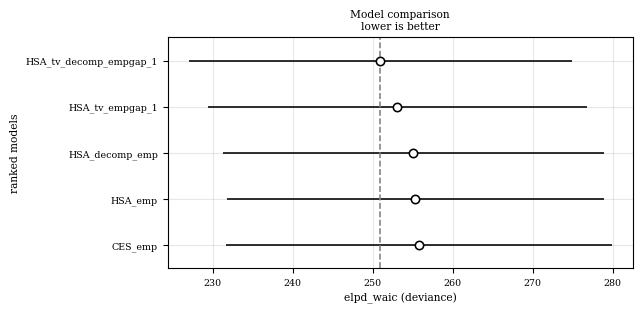

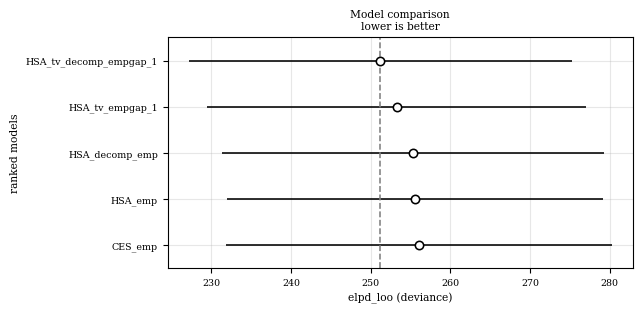

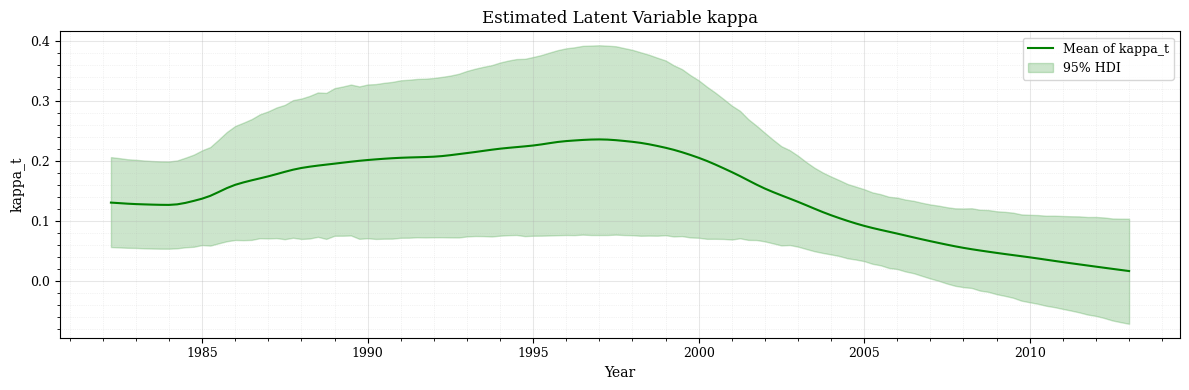

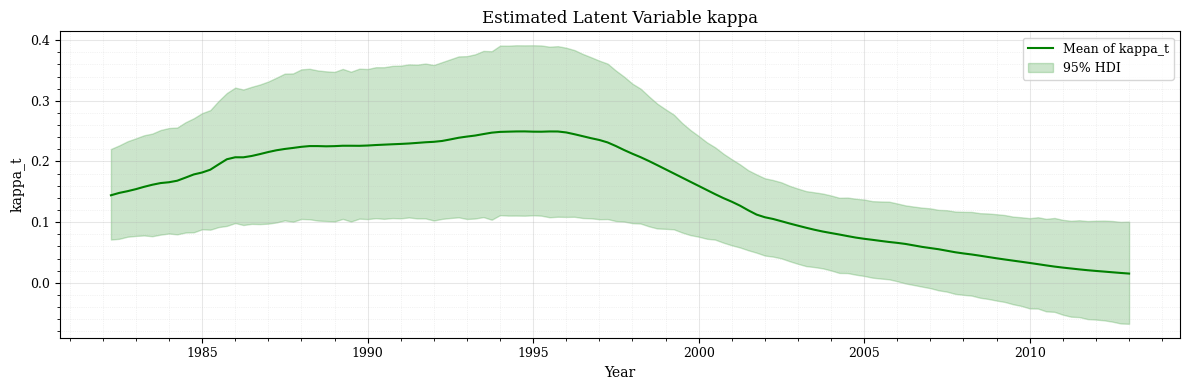

Model 'CES_emp' does not contain decomposed component in posterior
Model 'HSA_emp' does not contain decomposed component in posterior


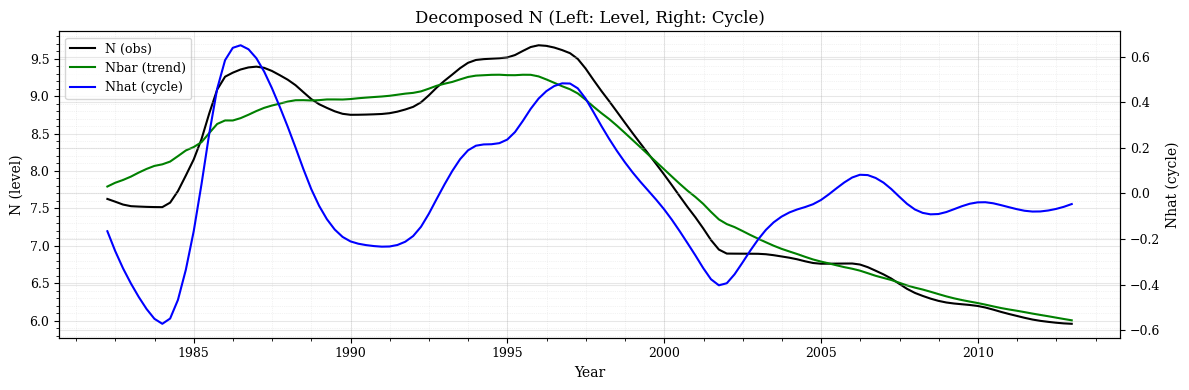

Model 'HSA_tv_empgap_1' does not contain decomposed component in posterior


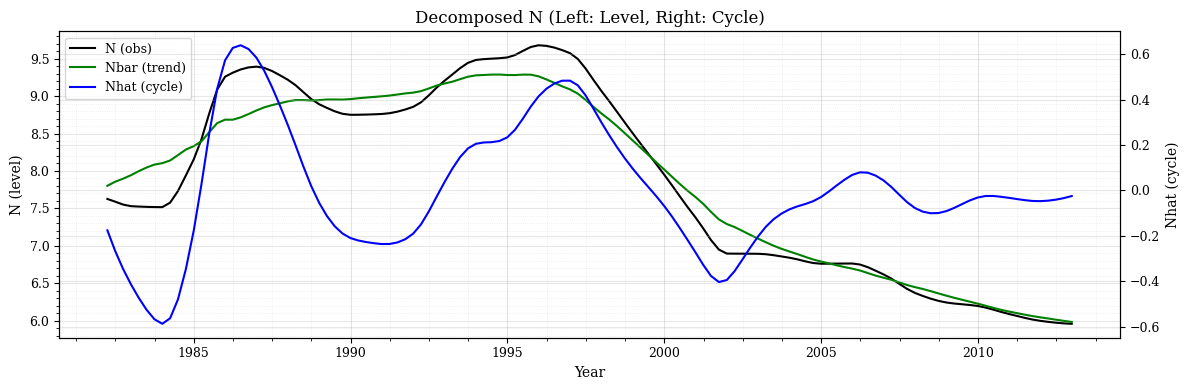

In [20]:
# results
models_to_show ={
    "CES_emp",
    "HSA_emp",
    "HSA_decomp_emp",
    "HSA_tv_empgap_1",
    "HSA_tv_empgap_2",
    "HSA_tv_empgap_3",
    "HSA_tv_decomp_empgap_1",
    "HSA_tv_decomp_empgap_2",
    "HSA_tv_decomp_empgap_3",
}
# dict_idata subset
dict_items_fill = {k: v for k, v in dict_idata.items() if k in models_to_show}
show_hdi = False
target_params = ["alpha", "kappa", "theta", "delta"]
# ------- Summary table -------
summ_list = []
for model_name, idata in dict_items_fill.items():
    present = set(idata.posterior.data_vars)
    selected = list(present.intersection(target_params))
    if len(selected) == 0:
        continue
    # ArviZ summary
    s = az.summary(idata, var_names=selected, hdi_prob=0.95)
    s["param"] = s.index
    s["model"] = model_name
    s = s.reset_index(drop=True)
    s = s[["model", "param", "mean", "hdi_2.5%", "hdi_97.5%"]]
    summ_list.append(s)
summary_long = pd.concat(summ_list, ignore_index=True)

# ---- HDI on/off ----
if show_hdi:
    summary_long["value"] = summary_long.apply(
        lambda r: f"{r['mean']:.4f} [{r['hdi_2.5%']:.4f}, {r['hdi_97.5%']:.4f}]",
        axis=1
    )
else:
    summary_long["value"] = summary_long["mean"].map(lambda x: f"{x:.4f}")

# pivot
summary_wide = (
    summary_long.pivot_table(
        index="model",
        columns="param",
        values="value",
        aggfunc="first",
    )
    .reindex(columns=target_params)
    .reset_index()
    .rename_axis(None, axis=1)
)

display(HTML("<h3>Summary</h3>"))
display(summary_wide.style.hide(axis="index"))

# SDDR（kappa / theta）table
sddr_rows = []
for model_name, idata in dict_items_fill.items():
    try:
        bf01_kappa = sddr_kappa(idata)
    except Exception:
        bf01_kappa = np.nan
    try:
        bf01_theta = sddr_theta(idata)
    except Exception:
        bf01_theta = np.nan
    try:
        bf01_delta = sddr_delta(idata)
    except Exception:
        bf01_delta = np.nan
    sddr_rows.append({
        "model": model_name,
        "SDDR_BF01_kappa": bf01_kappa,
        "SDDR_BF01_theta": bf01_theta,
        "SDDR_BF01_delta": bf01_delta,
    })

df_sddr = pd.DataFrame(sddr_rows)
df_sddr["SDDR_BF01_kappa"] = df_sddr["SDDR_BF01_kappa"].map(lambda v: f"{v:.4}")
df_sddr["SDDR_BF01_theta"] = df_sddr["SDDR_BF01_theta"].map(lambda v: f"{v:.4}")
df_sddr["SDDR_BF01_delta"] = df_sddr["SDDR_BF01_delta"].map(lambda v: f"{v:.4}")


display(HTML("<h3>SDDR: kappa: Bayes Factor (BF01)</h3>"))
display(df_sddr.style.hide(axis="index"))

display(HTML("<h3>prior vs posterior </h3>"))
# 6) prior vs posterior 
params = ("kappa", "theta", "delta")
try:
    idatas = [idata for _, idata in dict_items_fill.items()]
    labels  = [name for name, _ in dict_items_fill.items()]
    fig = plot_prior_posterior_grid(
            idatas=idatas,
            labels=labels,
            params=params,
            xlims={"kappa": (-0.15, 0.25), "alpha": (0.5, 1.0), "theta": (-0.4, 0.6), "delta": (-0.4, 0.6)})
    plt.show()
except Exception as e:
    print(f"[plot_prior_posterior_grid] error: {e}")


display(HTML("<h3>WAIC</h3>"))
df_waic = az.compare(dict_items_fill, var_name="pi_obs" ,ic='waic', scale='deviance')
az.plot_compare(df_waic, figsize=(6, 3))

display(HTML("<h3>LOO</h3>"))
df_waic = az.compare(dict_items_fill, var_name="pi_obs" ,ic='loo', scale='deviance')
az.plot_compare(df_waic, figsize=(6, 3))

# ===== Plot kappa_t for each model with 95% HDI =====
display(HTML("<h3>Latent Variable kappa_t (95% HDI) for Each Model</h3>"))
for model_name, idata in dict_items_fill.items():
    try:
        # Extract kappa_t samples from posterior
        if "kappa_t" in idata.posterior:
            kappa_samples = idata.posterior["kappa_t"].values
            # Flatten chain and draw dimensions: (chain, draw, time) -> (samples, time)
            kappa_samples = kappa_samples.reshape(-1, kappa_samples.shape[-1])
            
            # Calculate mean and 95% HDI using ArviZ
            kappa_mean = np.mean(kappa_samples, axis=0)
            kappa_hdi = az.hdi(kappa_samples, hdi_prob=0.95)
            kappa_lower = kappa_hdi[:, 0]
            kappa_upper = kappa_hdi[:, 1]
            
            # Moving average
            window = 5
            kappa_ma = pd.Series(kappa_mean).rolling(window=window, center=True).mean()
            
            # Plot
            plt.figure(figsize=(12, 4))
            plt.plot(data["DATE"], kappa_mean, label="Mean of kappa_t", color="green")
            plt.fill_between(data["DATE"], kappa_lower, kappa_upper, 
                           color="green", alpha=0.2, label="95% HDI")
            
            plt.title(f"Estimated Latent Variable kappa")
            plt.xlabel("Year")
            plt.ylabel("kappa_t")
            plt.legend()
            plt.minorticks_on()
            plt.grid(which='major', linestyle='-', linewidth=0.75)
            plt.grid(which='minor', linestyle=':', linewidth=0.5)
            
            ax = plt.gca()
            ax.xaxis.set_major_locator(mdates.YearLocator(5))
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
            ax.xaxis.set_minor_locator(mdates.YearLocator(1))
            plt.tight_layout()
            plt.show()
        else:
            print(f"Model '{model_name}' does not contain 'kappa_t' in posterior")
            
    except Exception as e:
        print(f"[kappa_t plot] {model_name} error: {e}")

display(HTML("<h3>Decomposed N for Each Model</h3>"))
for model_name, idata in dict_items_fill.items():
    try:
        if "Nbar_t" in idata.posterior:
            # Nhat
            Nhat_samples = idata.posterior["Nhat_t"].values
            Nhat_samples = Nhat_samples.reshape(-1, Nhat_samples.shape[-1])
            Nhat_mean = np.mean(Nhat_samples, axis=0)

            # Nbar
            Nbar_samples = idata.posterior["Nbar_t"].values
            Nbar_samples = Nbar_samples.reshape(-1, Nbar_samples.shape[-1])
            Nbar_mean = np.mean(Nbar_samples, axis=0)

            # Plot
            fig, ax1 = plt.subplots(figsize=(12, 4))

            # Left axis (levels)
            ax1.plot(data["DATE"], data["N"], label="N (obs)", color="black")
            ax1.plot(data["DATE"], Nbar_mean, label="Nbar (trend)", color="green")
            ax1.set_xlabel("Year")
            ax1.set_ylabel("N (level)")
            ax1.xaxis.set_major_locator(mdates.YearLocator(5))
            ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
            ax1.xaxis.set_minor_locator(mdates.YearLocator(1))

            # Right axis (cycle)
            ax2 = ax1.twinx()
            ax2.plot(data["DATE"], Nhat_mean, label="Nhat (cycle)", color="blue")
            ax2.set_ylabel("Nhat (cycle)")

            # Grid
            ax1.minorticks_on()
            ax1.grid(which='major', linestyle='-', linewidth=0.75)
            ax1.grid(which='minor', linestyle=':', linewidth=0.5)

            # Legend
            lines1, labels1 = ax1.get_legend_handles_labels()
            lines2, labels2 = ax2.get_legend_handles_labels()
            ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

            plt.title(f"Decomposed N (Left: Level, Right: Cycle)")
            plt.tight_layout()
            plt.show()

        else:
            print(f"Model '{model_name}' does not contain decomposed component in posterior")

    except Exception as e:
        print(f"[N_t plot] {model_name} error: {e}")

# Comparison

<Axes: title={'center': 'Model comparison\nlower is better'}, xlabel='elpd_loo (deviance)', ylabel='ranked models'>

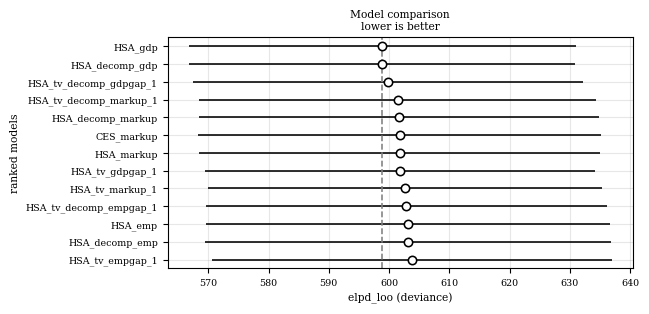

In [ ]:
# results
models_to_show ={
    "CES_empgap"
    "CES_gdp",
    "CES_markup",
    "HSA_emp",
    "HSA_gdp",
    "HSA_markup",
    "HSA_decomp_emp",
    "HSA_decomp_gdp",
    "HSA_decomp_markup",
    "HSA_tv_empgap_1",
    "HSA_tv_gdpgap_1",
    "HSA_tv_markup_1",
    "HSA_tv_decomp_empgap_1",
    "HSA_tv_decomp_gdpgap_1",
    "HSA_tv_decomp_markup_1",
}
# dict_idata を subset
dict_items_fill = {k: v for k, v in dict_idata.items() if k in models_to_show}

display(HTML("<h3>WAIC</h3>"))
df_waic = az.compare(dict_items_fill, var_name="pi_obs" ,ic='loo', scale='deviance')
az.plot_compare(df_waic, figsize=(6, 3))
